### Carga de paquetes necesarios
Aquí cargué las los paquetes y librerías que me permitirán trabajar con los datos

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Configuración Básica para los Gráficos

In [16]:
# Configuración estética básica para todos los gráficos
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### Cargo el archivo csv y lo convierto a parquet para mayor comodidad

In [17]:
# importar el archivo csv
df = pd.read_csv('discharge_klu.csv', skiprows=4, names=["timestamp", "caudal_m3s"], header=None)
# parsear la columna timestamp a datetime y agregar zona horaria.
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
# indexamos por tiempo y ordeno cronológicamente
df = df.set_index('timestamp').sort_index()
# convierto a parquet para mejor manejo y portabilidad
df.to_parquet('discharge_klu.parquet', compression='snappy')

# cargamos el archivo .parquet
df_pq = pd.read_parquet('discharge_klu.parquet')
# compruebo los tipos de datos
print(f"Tipo del índice:   {df_pq.index.dtype}")
print(f"Tipo de la columna: {df_pq['caudal_m3s'].dtype}")

# comprobación de datos faltantes o nulos
print("Valores NaN por columna: ")
print(df_pq.isna().sum())

# verificar si hay duplicados
print("Timestamps duplicados: ", df_pq.index.duplicated().sum())

# Calcular el delta de tiempo entre observaciones consecutivas
deltas = df.index.to_series().diff().dropna()
print(" Calcular medidas estadísticas básicas como media, mediana, mínimo y máximo")
print(deltas.describe())

Tipo del índice:   datetime64[ns, UTC]
Tipo de la columna: float64
Valores NaN por columna: 
caudal_m3s    0
dtype: int64
Timestamps duplicados:  0
 Calcular medidas estadísticas básicas como media, mediana, mínimo y máximo
count                      1375032
mean     0 days 00:06:07.207141361
std      0 days 00:12:39.094766918
min                0 days 00:00:05
25%                0 days 00:02:00
50%                0 days 00:05:00
75%                0 days 00:05:00
max                1 days 12:30:00
Name: timestamp, dtype: object


### Gráfico de la Serie

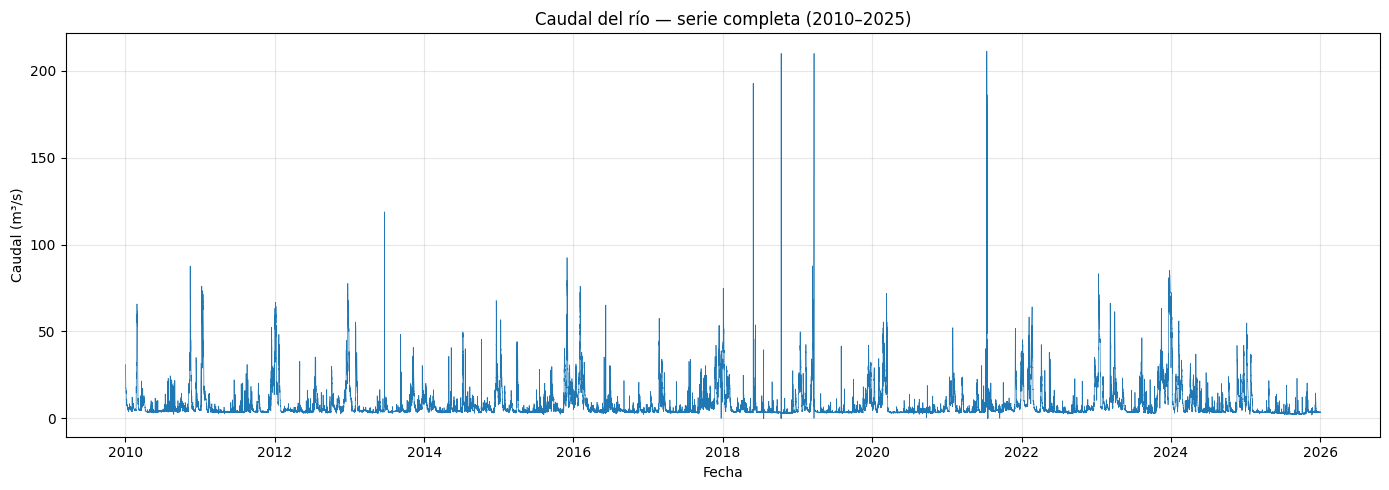

In [18]:
plt.figure()
plt.plot(df.index, df['caudal_m3s'], linewidth=0.5)
plt.title('Caudal del río — serie completa (2010–2025)')
plt.xlabel('Fecha')
plt.ylabel('Caudal (m³/s)')
plt.tight_layout()
plt.show()

### Estacionalidad Anual

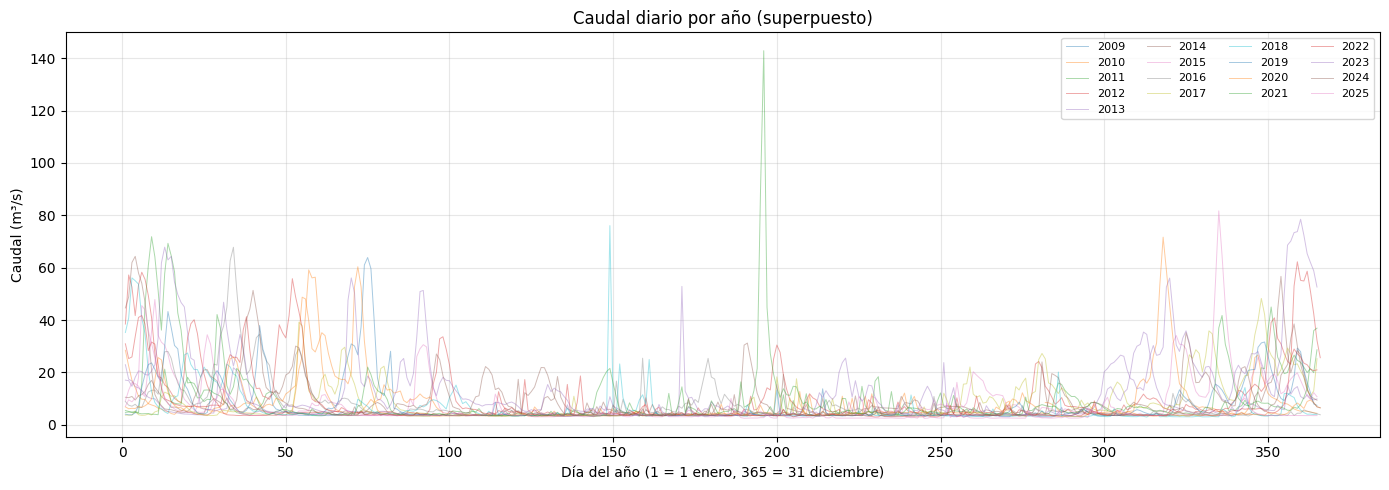

In [19]:
diario = df['caudal_m3s'].resample('D').mean()

# Convertir a DataFrame y agregar columnas auxiliares
diario_df = diario.to_frame()
diario_df['año']        = diario_df.index.year
diario_df['dia_del_año'] = diario_df.index.dayofyear

plt.figure()
for año, grupo in diario_df.groupby('año'):
    plt.plot(grupo['dia_del_año'], grupo['caudal_m3s'],
             linewidth=0.7, alpha=0.4, label=str(año))

plt.title('Caudal diario por año (superpuesto)')
plt.xlabel('Día del año (1 = 1 enero, 365 = 31 diciembre)')
plt.ylabel('Caudal (m³/s)')
plt.legend(ncol=4, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

### Boxplot

Observaciones diarias: 5841
Rango: 2009-12-31 → 2025-12-31


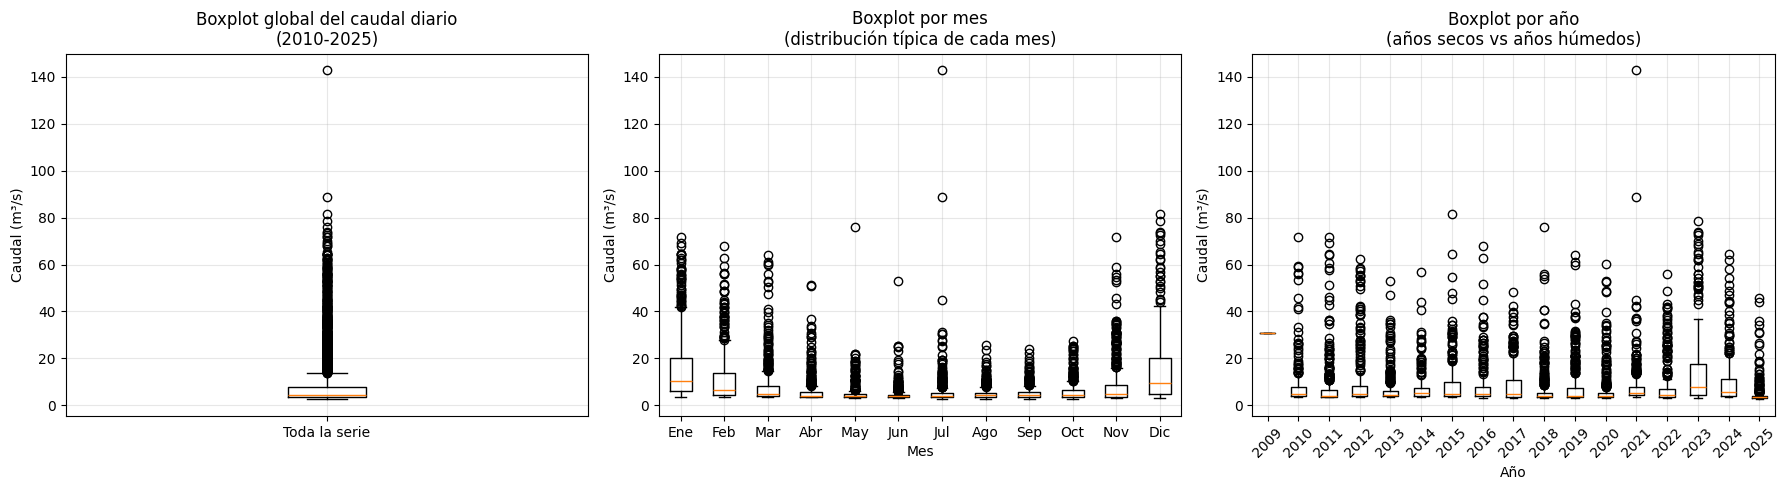

In [20]:
# Remuestreo a frecuencia diaria (promedio del día)
caudal_diario = df['caudal_m3s'].resample('D').mean().dropna()

print(f"Observaciones diarias: {len(caudal_diario)}")
print(f"Rango: {caudal_diario.index.min().date()} → {caudal_diario.index.max().date()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- 1. Boxplot global (toda la serie de un solo trago) ----
axes[0].boxplot(caudal_diario, vert=True)
axes[0].set_title('Boxplot global del caudal diario\n(2010-2025)')
axes[0].set_ylabel('Caudal (m³/s)')
axes[0].set_xticklabels(['Toda la serie'])
axes[0].grid(alpha=0.3)

# ---- 2. Boxplot por mes (revela estacionalidad anual) ----
datos_por_mes = [caudal_diario[caudal_diario.index.month == m] for m in range(1, 13)]
axes[1].boxplot(datos_por_mes, tick_labels=['Ene','Feb','Mar','Abr','May','Jun',
                                       'Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].set_title('Boxplot por mes\n(distribución típica de cada mes)')
axes[1].set_ylabel('Caudal (m³/s)')
axes[1].set_xlabel('Mes')
axes[1].grid(alpha=0.3)

# ---- 3. Boxplot por año (revela cambios interanuales) ----
años = sorted(caudal_diario.index.year.unique())
datos_por_año = [caudal_diario[caudal_diario.index.year == a] for a in años]
axes[2].boxplot(datos_por_año, tick_labels=[str(a) for a in años])
axes[2].set_title('Boxplot por año\n(años secos vs años húmedos)')
axes[2].set_ylabel('Caudal (m³/s)')
axes[2].set_xlabel('Año')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Distribución (histograma + KDE)

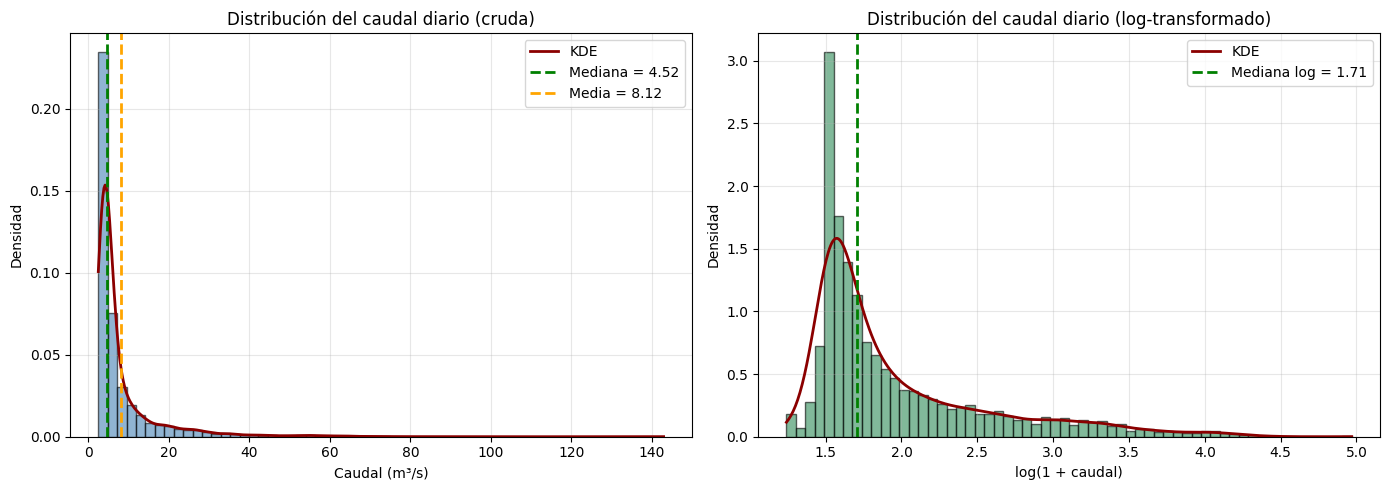

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- 1. Distribución cruda ----
axes[0].hist(caudal_diario, bins=60, density=True, alpha=0.6,
             color='steelblue', edgecolor='black')

# Superponer KDE manualmente con scipy
from scipy.stats import gaussian_kde
kde = gaussian_kde(caudal_diario)
x_grid = np.linspace(caudal_diario.min(), caudal_diario.max(), 500)
axes[0].plot(x_grid, kde(x_grid), color='darkred', linewidth=2, label='KDE')

# Marcar mediana y media
axes[0].axvline(caudal_diario.median(), color='green', linestyle='--',
                linewidth=2, label=f'Mediana = {caudal_diario.median():.2f}')
axes[0].axvline(caudal_diario.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Media = {caudal_diario.mean():.2f}')

axes[0].set_title('Distribución del caudal diario (cruda)')
axes[0].set_xlabel('Caudal (m³/s)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- 2. Distribución con escala logarítmica ----
log_caudal = np.log1p(caudal_diario)   # log(1 + x) para evitar problemas si hay ceros

axes[1].hist(log_caudal, bins=60, density=True, alpha=0.6,
             color='seagreen', edgecolor='black')

kde_log = gaussian_kde(log_caudal)
x_grid_log = np.linspace(log_caudal.min(), log_caudal.max(), 500)
axes[1].plot(x_grid_log, kde_log(x_grid_log), color='darkred', linewidth=2, label='KDE')

axes[1].axvline(log_caudal.median(), color='green', linestyle='--',
                linewidth=2, label=f'Mediana log = {log_caudal.median():.2f}')

axes[1].set_title('Distribución del caudal diario (log-transformado)')
axes[1].set_xlabel('log(1 + caudal)')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones del diagnóstico

1. La frecuencia base es de 5 minutos. No de 15 como yo había estimado al principio mirando solo las primeras filas. La mediana y Q3 lo confirman: ese es el ritmo nominal del sensor.
2. El sensor tiene reportes de alta frecuencia (cada 1-2 minutos o menos) en parte del tiempo. El Q1 = 2 min y el mínimo = 5 segundos lo evidencian. Esto es probablemente un comportamiento intencionado del equipo: reportar más rápido cuando el caudal cambia rápido.
3. La serie tiene huecos reales. El máximo de 36.5 horas es prueba de ello. Hace falta cuantificar cuántos huecos grandes hay y cuándo ocurrieron.
4. La serie es irregular. Promedio (6 min), mediana (5 min), Q1 (2 min) y máximo (36 h) muestran una distribución muy dispersa. No se puede asumir frecuencia regular para modelado.